# **Exercises**

# **Question 1**

```
1. Try to build a classifier for the MNIST dataset that achieves over 97% accuracy
on the test set. Hint: the KNeighborsClassifier works quite well for this task;
you just need to find good hyperparameter values (try a grid search on the
weights and n_neighbors hyperparameters).
```



so its multilabel from 0 to 9, we will use multioutput multi classifier

In [1]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler


In [2]:
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)


In [3]:
print(len(X))
print(len(y))


70000
70000


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [5]:
print(len(X_train))
print(len(y_train))
print(len(X_test))
print(len(y_test))

52500
52500
17500
17500


In [6]:
# y0 = (y_train.astype(int) ==  0)
# y1 = (y_train.astype(int) ==  1)
# y2 = (y_train.astype(int) ==  2)
# y3 = (y_train.astype(int) ==  3)
# y4 = (y_train.astype(int) ==  4)
# y5 = (y_train.astype(int) ==  5)
# y6 = (y_train.astype(int) ==  6)
# y7 = (y_train.astype(int) ==  7)
# y8 = (y_train.astype(int) ==  8)
# y9 = (y_train.astype(int) ==  9)

In [7]:
# y_multilabel = np.c_[y0,y1,y2,y3,y4,y5,y6,y7,y8,y9]

In [8]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('ss', StandardScaler()),
    ('knn', KNeighborsClassifier())
])


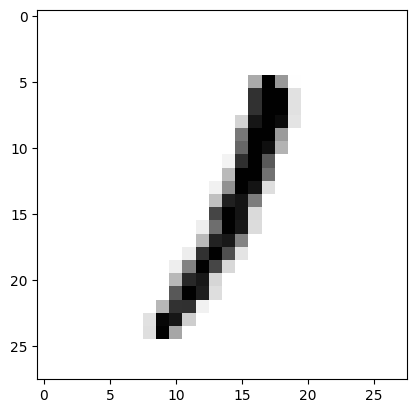

In [13]:
import matplotlib
digit_image = digit.reshape(28,28)

%matplotlib inline
plt.imshow(digit_image, cmap=matplotlib.cm.binary, interpolation='nearest')
plt.show()

In [9]:
param_grid = {
    'knn__n_neighbors': [3,5,7,9],
    'knn__weights': ['distance', 'uniform'],
}


# ------------- model ----------------

# (n_neighbors: int = 5, *, weights: str = "uniform", algorithm: str = "auto", leaf_size: int = 30, p: int = 2, metric: str = "minkowski", metric_params: Any | None = None, n_jobs: Any | None = None) -> KNeighborsClassifier

In [10]:
# (estimator: Any, param_grid: Any, *, scoring: Any | None = None, n_jobs: Any | None = None, refit: bool = True, cv: Any | None = None, verbose: int = 0, pre_dispatch: str = "2*n_jobs", error_score: float = np.nan, return_train_score: bool = False) -> GridSearchCV

gscv = GridSearchCV(pipe, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2, scoring='accuracy')
gscv

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('ss', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'knn__n_neighbors': [3, 5, 7, 9],
                         'knn__weights': ['distance', 'uniform']},
             scoring='accuracy', verbose=2)

In [17]:
gscv.fit(X_train, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


GridSearchCV(cv=3, estimator=KNeighborsClassifier(), n_jobs=4,
             param_grid={'n_neighbors': [3, 5, 7, 9],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy', verbose=2)

In [18]:
gscv.best_params_

{'n_neighbors': 3, 'weights': 'distance'}

In [19]:
gscv.best_estimator_

KNeighborsClassifier(n_neighbors=3, weights='distance')

In [20]:
gscv.cv_results_

{'mean_fit_time': array([1.41361237, 1.05351949, 0.74063532, 0.52049239, 0.62930759,
        0.62454796, 0.6184814 , 0.47264425]),
 'std_fit_time': array([0.45071313, 0.48099647, 0.10832786, 0.03071972, 0.05552017,
        0.12549845, 0.16893423, 0.0538624 ]),
 'mean_score_time': array([192.74787092, 169.46167699, 162.61599517, 164.89799515,
        159.58832892, 160.36327346, 159.25320005, 158.53760688]),
 'std_score_time': array([ 1.68502646, 15.71492035,  2.53392752,  0.97254153,  3.16713304,
         2.93645741,  1.67351783,  1.12274099]),
 'param_n_neighbors': masked_array(data=[3, 3, 5, 5, 7, 7, 9, 9],
              mask=[False, False, False, False, False, False, False, False],
        fill_value=999999),
 'param_weights': masked_array(data=['uniform', 'distance', 'uniform', 'distance',
                    'uniform', 'distance', 'uniform', 'distance'],
              mask=[False, False, False, False, False, False, False, False],
        fill_value=np.str_('?'),
             dtype=

In [25]:
accuracy = gscv.best_estimator_.score(X_test, y_test)
print()

0.9721714285714286


# **Question 2**


```
2. Write a function that can shift an MNIST image in any direction (left, right, up,
or down) by one pixel.5 Then, for each image in the training set, create four shif‐
ted copies (one per direction) and add them to the training set. Finally, train your
best model on this expanded training set and measure its accuracy on the test set.
You should observe that your model performs even better now! This technique of artificially growing the training set is called data augmentation or training set
expansion.
```

In [11]:
def shift_image(image, direction):

    img = image.reshape(28, 28)

    shifted = np.zeros_like(img)

    if direction == "left":
        shifted[:, :-1] = img[:, 1:]
    elif direction == "right":
        shifted[:, 1:] = img[:, :-1]
    elif direction == "up":
        shifted[:-1, :] = img[1:, :]
    elif direction == "down":
        shifted[1:, :] = img[:-1, :]
    else:
        raise ValueError("Invalid direction")

    return shifted.reshape(-1)

In [12]:
X_aug = []
y_aug = []
for image, label in zip(X_train, y_train):

  X_aug.append(image)
  y_aug.append(label)

  X_aug.append(shift_image(image, 'left'))
  X_aug.append(shift_image(image, 'right'))
  X_aug.append(shift_image(image, 'up'))
  X_aug.append(shift_image(image, 'down'))

  y_aug.extend([label,label,label,label])

X_train_aug = np.array(X_aug)
y_train_aug = np.array(y_aug)

In [ ]:
pipe = Pipeline([
    ('ss', StandardScaler()),
    ('knn', KNeighborsClassifier(
        n_neighbors=3,
        weights='distance'
    ))
])

Pipeline(steps=[('ss', StandardScaler()),
                ('knn',
                 KNeighborsClassifier(n_neighbors=3, weights='distance'))])

In [18]:
pipe.fit(X_train_aug, y_train_aug)


Pipeline(steps=[('ss', StandardScaler()),
                ('knn',
                 KNeighborsClassifier(n_neighbors=3, weights='distance'))])

In [19]:
accuracy = pipe.score(X_test, y_test)

In [20]:
print(accuracy)

0.9603428571428572
